In [25]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw

In [26]:
product, time_reso, spatial_reso = 'IMERG', '1dy', 10
# product, time_reso, spatial_reso = 'CMORPH', '3h', 25
# product, time_reso, spatial_reso = 'MSWEP', '3h', 10
# product, time_reso, spatial_reso = 'ERA5', '3h', 25
# product, time_reso, spatial_reso = 'GSMaP', '3h', 10
# product, time_reso, spatial_reso = 'CHIRPS', '1dy', 10

In [27]:
npix = 2
tscale = 24
method = 'pearson'

In [28]:
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'Italy', 0.002
# lon_min, lon_max, lat_min, lat_max, area, toll = 10.5, 13.5, 44.5, 47, 'Veneto', 0.002

In [29]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [30]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [31]:
if product == 'IMERG':
    filename = 'IMERG_Italy_1dy_2000_06_01_2024_02_29.nc'

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'

else:
    sys.exit('Product not found')

In [ ]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)

# italy_geom = ITALY.union_all()
# mask_italy = sv.contains(italy_geom, lon2d, lat2d)
# DATA['PRE'] = DATA.PRE.where(mask_italy)

PRE_study = DATA.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

lat_ref = PRE_study.lat.values
lon_ref = PRE_study.lon.values

del PRE_study

Product: IMERG


In [33]:
lat_c = lat_ref[int(len(lat_ref)/2)]
lon_c = lon_ref[int(len(lon_ref)/2)]

box_3h = DOWN_raw.create_box_v2(DATA, lat_c, lon_c, npix)
DAILY = box_3h.resample(time ='{}h'.format(tscale)).sum(dim='time', skipna=False)
DAILY = DAILY.dropna(dim='time', how='all')

rcorr_ref = DOWN_raw.grid_corr(DAILY.PRE, plot=False, thresh=1, cor_method='pearson')
rcorr_ref = pd.DataFrame(rcorr_ref)
xdist = rcorr_ref.sort_values(by='vdist')['vdist'].values
pd_xdist = pd.DataFrame({'dist':xdist})

dir_out = os.path.join('..','..','output','autocorr','dist',f'{area}_{product}_Npix_{npix}.csv')
print(f'Export dataframe to: {dir_out}')
pd_xdist.to_csv(dir_out, header=True, index=False)

Export dataframe to: ../../output/autocorr/dist/Italy_IMERG_Npix_2.csv


In [34]:
def process_point(la, lo):
    try:
        lat_c = lat_ref[la]
        lon_c = lon_ref[lo]

        box_3h = DOWN_raw.create_box_v2(DATA, lat_c, lon_c, npix)
        DAILY = box_3h.resample(time=f'{tscale}h').sum(dim='time', skipna=False)
        DAILY = DAILY.dropna(dim='time', how='all')

        rcorr = DOWN_raw.grid_corr(
            DAILY.PRE,
            plot=False,
            thresh=1,
            cor_method='pearson'
        )

        return (lat_c, lon_c, rcorr['eps_s'], rcorr['alp_s'])

    except:
        return None


results = Parallel(n_jobs=20, backend="loky")(
    delayed(process_point)(la, lo)
    for la in range(len(lat_ref))
    for lo in range(len(lon_ref))
)

# filtra falhas
results = [r for r in results if r is not None]

# dataframe final
pd_corr = pd.DataFrame(results, columns=['lat','lon','epsilon','alpha'])

In [35]:
dir_out = os.path.join('..','..','output','autocorr','data',f'{area}_{product}_Npix_{npix}_mar_{method}.csv')
print(f'Export dataframe to: {dir_out}')
pd_corr.to_csv(dir_out, header=True, index=False)

Export dataframe to: ../../output/autocorr/data/Italy_IMERG_Npix_2_mar_pearson.csv


(0.1, 1.0)

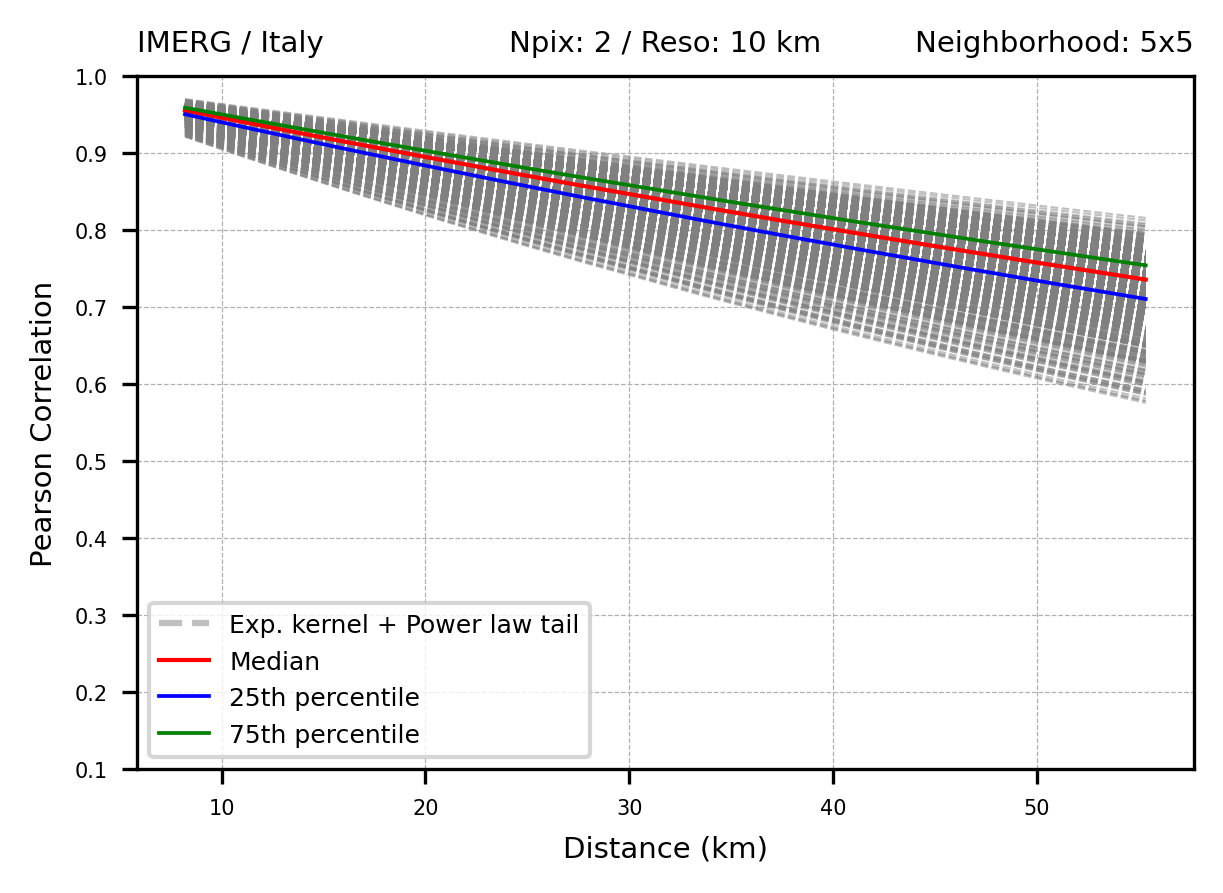

In [ ]:
xx = pd_xdist.values

fig = plt.figure(figsize=(10, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)

#==========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(pd_corr)):
    y_vals = DOWN_raw.epl_fun(xx, pd_corr['epsilon'].iloc[nn], pd_corr['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    ax1.plot(xx, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

matriz_curvas = np.array(todas_las_curvas)

median = np.median(matriz_curvas, axis=0)
p25 = np.percentile(matriz_curvas, 25, axis=0)
p75 = np.percentile(matriz_curvas, 75, axis=0)

ax1.plot(xx, median, linewidth=1, linestyle='-', color='red', label='Median')
ax1.plot(xx, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
ax1.plot(xx, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

ax1.tick_params(axis='both', which='major', labelsize=5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.legend(fontsize=6,loc=3)

ax1.set_title(f'{product} / {area}', loc='left', fontsize=7)
ax1.set_title(f'Npix: {npix} / Reso: {spatial_reso} km',loc='center',fontsize=7)
ax1.set_title(f'Neighborhood: {npix*2+1}x{npix*2+1}', loc='right', fontsize=7)
ax1.set_ylabel('Pearson Correlation',fontsize=7)
ax1.set_xlabel('Distance (km)',fontsize=7)

ax1.set_ylim(0.1,1)